# Sensor Parameters vs. Biometric Privacy Analysis


In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

results_dir = 'results/useful'


### Task 1: Data Aggregation & Comprehensive Performance Table


In [3]:
# Task 1: Data Aggregation
data = []

# Loop through the directory
for folder in sorted(os.listdir(results_dir)):
    folder_path = os.path.join(results_dir, folder)
    if os.path.isdir(folder_path):
        json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
        csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
        
        if json_files and csv_files:
            # Clean up config name
            config_name = folder.replace('retrieval_results_', '').replace('_300clips', '')
            
            with open(os.path.join(folder_path, json_files[0]), 'r') as f:
                j_data = json.load(f)
                
            # Extract metrics
            cross_results = j_data.get('results_cross', {})
            struct_metrics = j_data.get('structural_metrics', {})
            
            row = {
                'Configuration': config_name,
                'Mean SSIM': struct_metrics.get('mean_ssim', np.nan),
                'SD SSIM': struct_metrics.get('sd_ssim', np.nan),
                'Mean PSNR': struct_metrics.get('mean_psnr', np.nan),
                'SD PSNR': struct_metrics.get('sd_psnr', np.nan),
                'Rank-1': cross_results.get('rank1', np.nan),
                'mAP': cross_results.get('mAP', np.nan),
                'ASR': cross_results.get('asr', np.nan),
                'CSV_Path': os.path.join(folder_path, csv_files[0]) # Stored for Task 4
            }
            data.append(row)

df_macro = pd.DataFrame(data).set_index('Configuration')

# Identify baseline
baseline_idx = [i for i in df_macro.index if 'baseline' in i.lower()]
baseline_name = baseline_idx[0] if baseline_idx else df_macro.index[0]

# Display as markdown table
styled_df = df_macro.drop(columns=['CSV_Path']).round(4).style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', 'white'), ('color', 'black'), ('border', '1px solid black'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('background-color', 'white'), ('color', 'black'), ('border', '1px solid black'), ('padding', '8px')]},
    {'selector': 'table', 'props': [('background-color', 'white'), ('color', 'black'), ('border-collapse', 'collapse')]}
])
display(styled_df)


,Mean SSIM,SD SSIM,Mean PSNR,SD PSNR,Rank-1,mAP,ASR
Configuration,,,,,,,
baseline,1.0000,0.0000,60.0000,0.0000,0.5098,0.4743,0.5098
contrast_1,0.6825,0.3455,21.5556,12.9986,0.2941,0.2483,0.2941
cutoff_100,0.8073,0.3062,27.9284,14.7623,0.5882,0.4922,0.5882
leak_5,0.7337,0.3617,26.4514,14.9348,0.2157,0.1730,0.2157
on_symmetry,0.5999,0.4062,20.1695,14.2704,0.5294,0.4656,0.5294
resolution_640,0.5560,0.3988,19.7021,15.8493,0.0980,0.1279,0.0980


### Task 2: The Privacy-Utility Scatter Spaces (2x2 Grid)


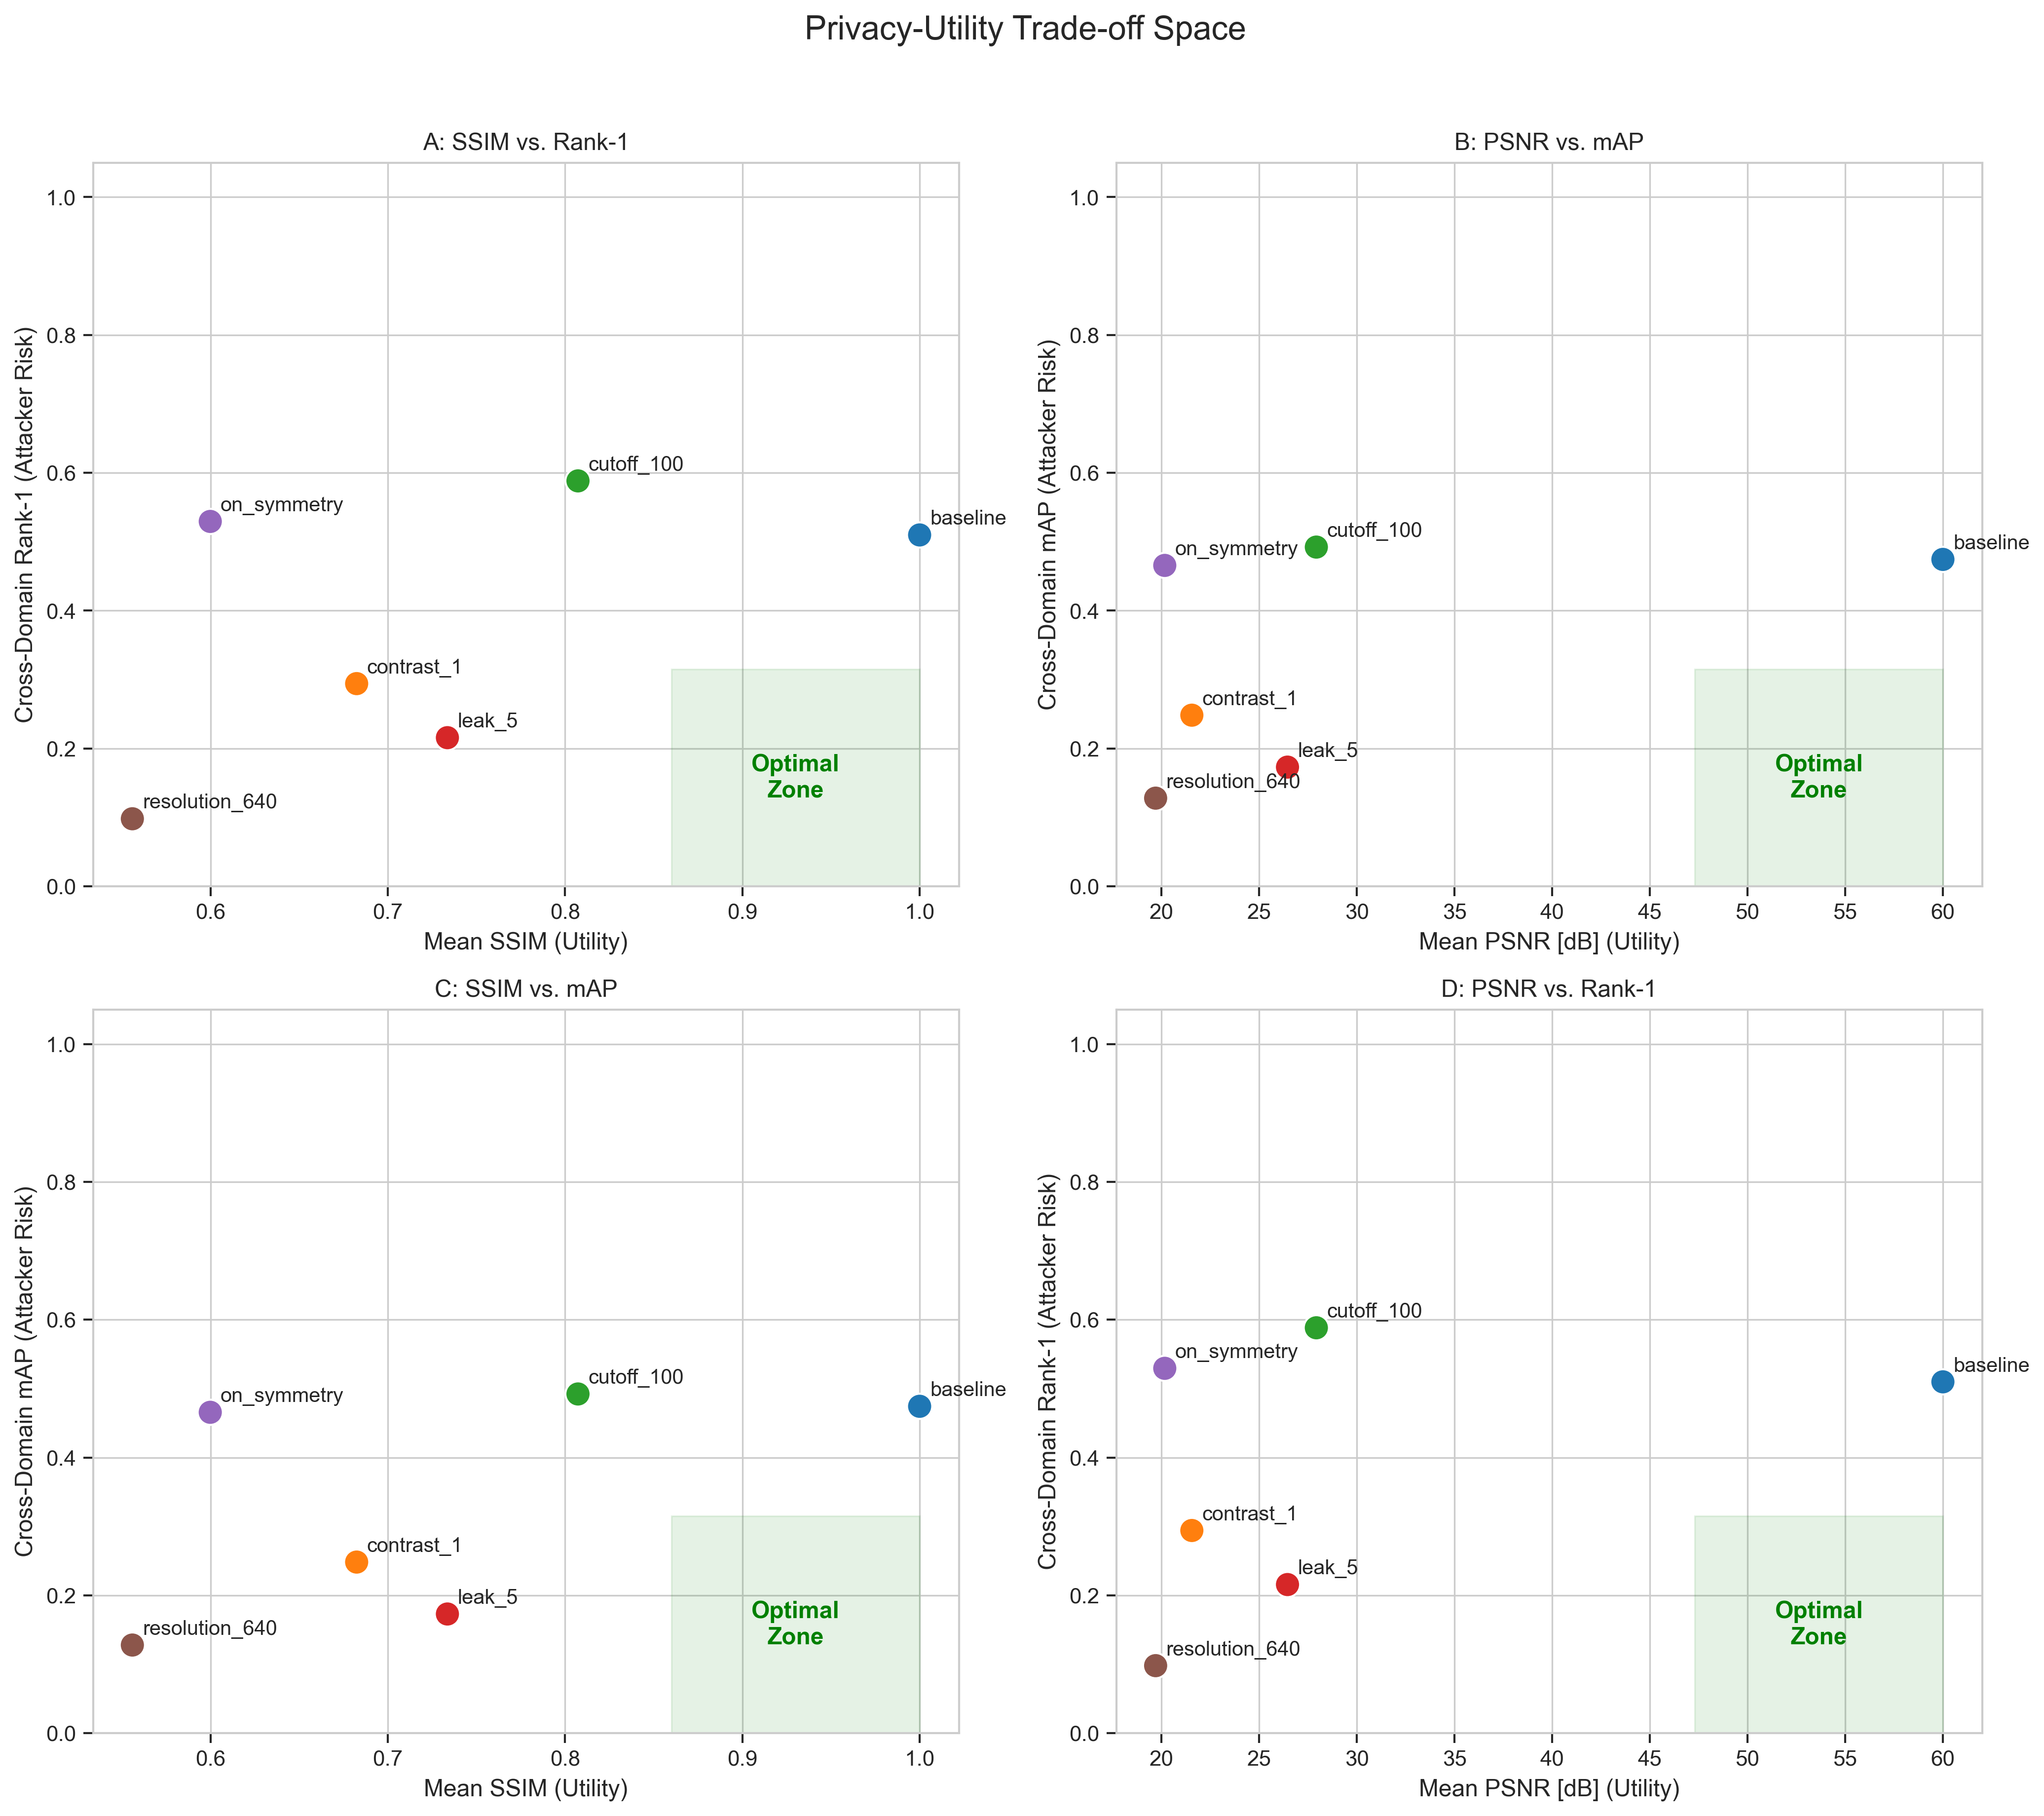

In [4]:
# Task 2: 2x2 Scatter Grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
fig.suptitle('Privacy-Utility Trade-off Space', fontsize=16, y=1.02)

# Extract Data
x_ssim = df_macro['Mean SSIM']
y_rank1 = df_macro['Rank-1']
x_psnr = df_macro['Mean PSNR']
y_map = df_macro['mAP']

configs = df_macro.index.tolist()

def plot_scatter(ax, x, y, xlabel, ylabel, title):
    sns.scatterplot(x=x, y=y, hue=configs, s=150, ax=ax, legend=False, palette='tab10')
    for i, config in enumerate(configs):
        # Use .iloc to safely access elements by integer index
        ax.annotate(config, (x.iloc[i], y.iloc[i]), xytext=(5, 5), textcoords='offset points', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    
    # Highlight optimal zone (bottom right: High Utility, Low Risk)
    x_min, x_max = ax.get_xlim()
    x_max_bound = x_max
    if 'SSIM' in xlabel:
        x_max_bound = min(x_max, 1.0)
    elif 'PSNR' in xlabel:
        x_max_bound = min(x_max, 60.0)
    y_min, y_max = ax.get_ylim()
    # Draw green shaded region
    ax.axvspan(x_min + (x_max_bound-x_min)*0.7, x_max_bound, ymin=0, ymax=0.3, color='green', alpha=0.1)
    ax.text(x_max_bound - (x_max_bound-x_min)*0.15, y_min + (y_max-y_min)*0.15, 'Optimal\nZone', color='green', ha='center', va='center', fontweight='bold')

# A: SSIM vs Rank-1
plot_scatter(axes[0, 0], x_ssim, y_rank1, 'Mean SSIM (Utility)', 'Cross-Domain Rank-1 (Attacker Risk)', 'A: SSIM vs. Rank-1')

# B: PSNR vs mAP
plot_scatter(axes[0, 1], x_psnr, y_map, 'Mean PSNR [dB] (Utility)', 'Cross-Domain mAP (Attacker Risk)', 'B: PSNR vs. mAP')

# C: SSIM vs mAP
plot_scatter(axes[1, 0], x_ssim, y_map, 'Mean SSIM (Utility)', 'Cross-Domain mAP (Attacker Risk)', 'C: SSIM vs. mAP')

# D: PSNR vs Rank-1
plot_scatter(axes[1, 1], x_psnr, y_rank1, 'Mean PSNR [dB] (Utility)', 'Cross-Domain Rank-1 (Attacker Risk)', 'D: PSNR vs. Rank-1')

plt.tight_layout()
plt.show()


### Task 3: Multi-Metric "Delta" Bar Chart


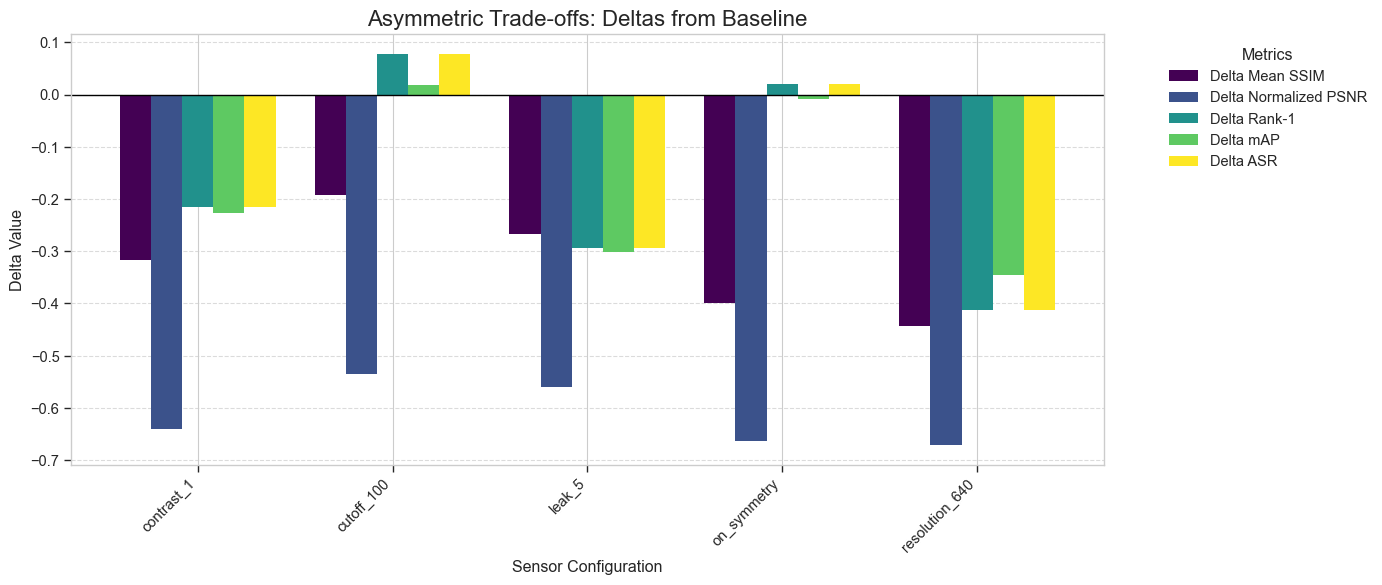

In [5]:
# Task 3: Deltas from Baseline
df_delta = df_macro.drop(columns=['CSV_Path']).copy()

for col in df_delta.columns:
    df_delta[f'Delta {col}'] = df_delta[col] - df_macro.loc[baseline_name, col]

# Normalize PSNR delta (percentage drop relative to baseline PSNR)
base_psnr = df_macro.loc[baseline_name, 'Mean PSNR']
if base_psnr > 0:
    df_delta['Delta Normalized PSNR'] = df_delta['Delta Mean PSNR'] / base_psnr
else:
    df_delta['Delta Normalized PSNR'] = df_delta['Delta Mean PSNR']

delta_cols = ['Delta Mean SSIM', 'Delta Normalized PSNR', 'Delta Rank-1', 'Delta mAP', 'Delta ASR']
df_plot = df_delta[delta_cols].drop(index=baseline_name) # Remove baseline itself

ax = df_plot.plot(kind='bar', figsize=(14, 6), width=0.8, colormap='viridis')
plt.title('Asymmetric Trade-offs: Deltas from Baseline', fontsize=16)
plt.ylabel('Delta Value')
plt.xlabel('Sensor Configuration')
plt.axhline(0, color='black', linewidth=1)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Task 4: Per-Clip Metric Distribution Boxplots


C:\Users\sofya\AppData\Local\Temp\ipykernel_1516\1043038331.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Configuration', y='ssim', ax=axes[0], palette='Set2')
C:\Users\sofya\AppData\Local\Temp\ipykernel_1516\1043038331.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Configuration', y='psnr', ax=axes[1], palette='Set2')
C:\Users\sofya\AppData\Local\Temp\ipykernel_1516\1043038331.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_queries, x='Configuration', y='average_precision', ax=axes[2

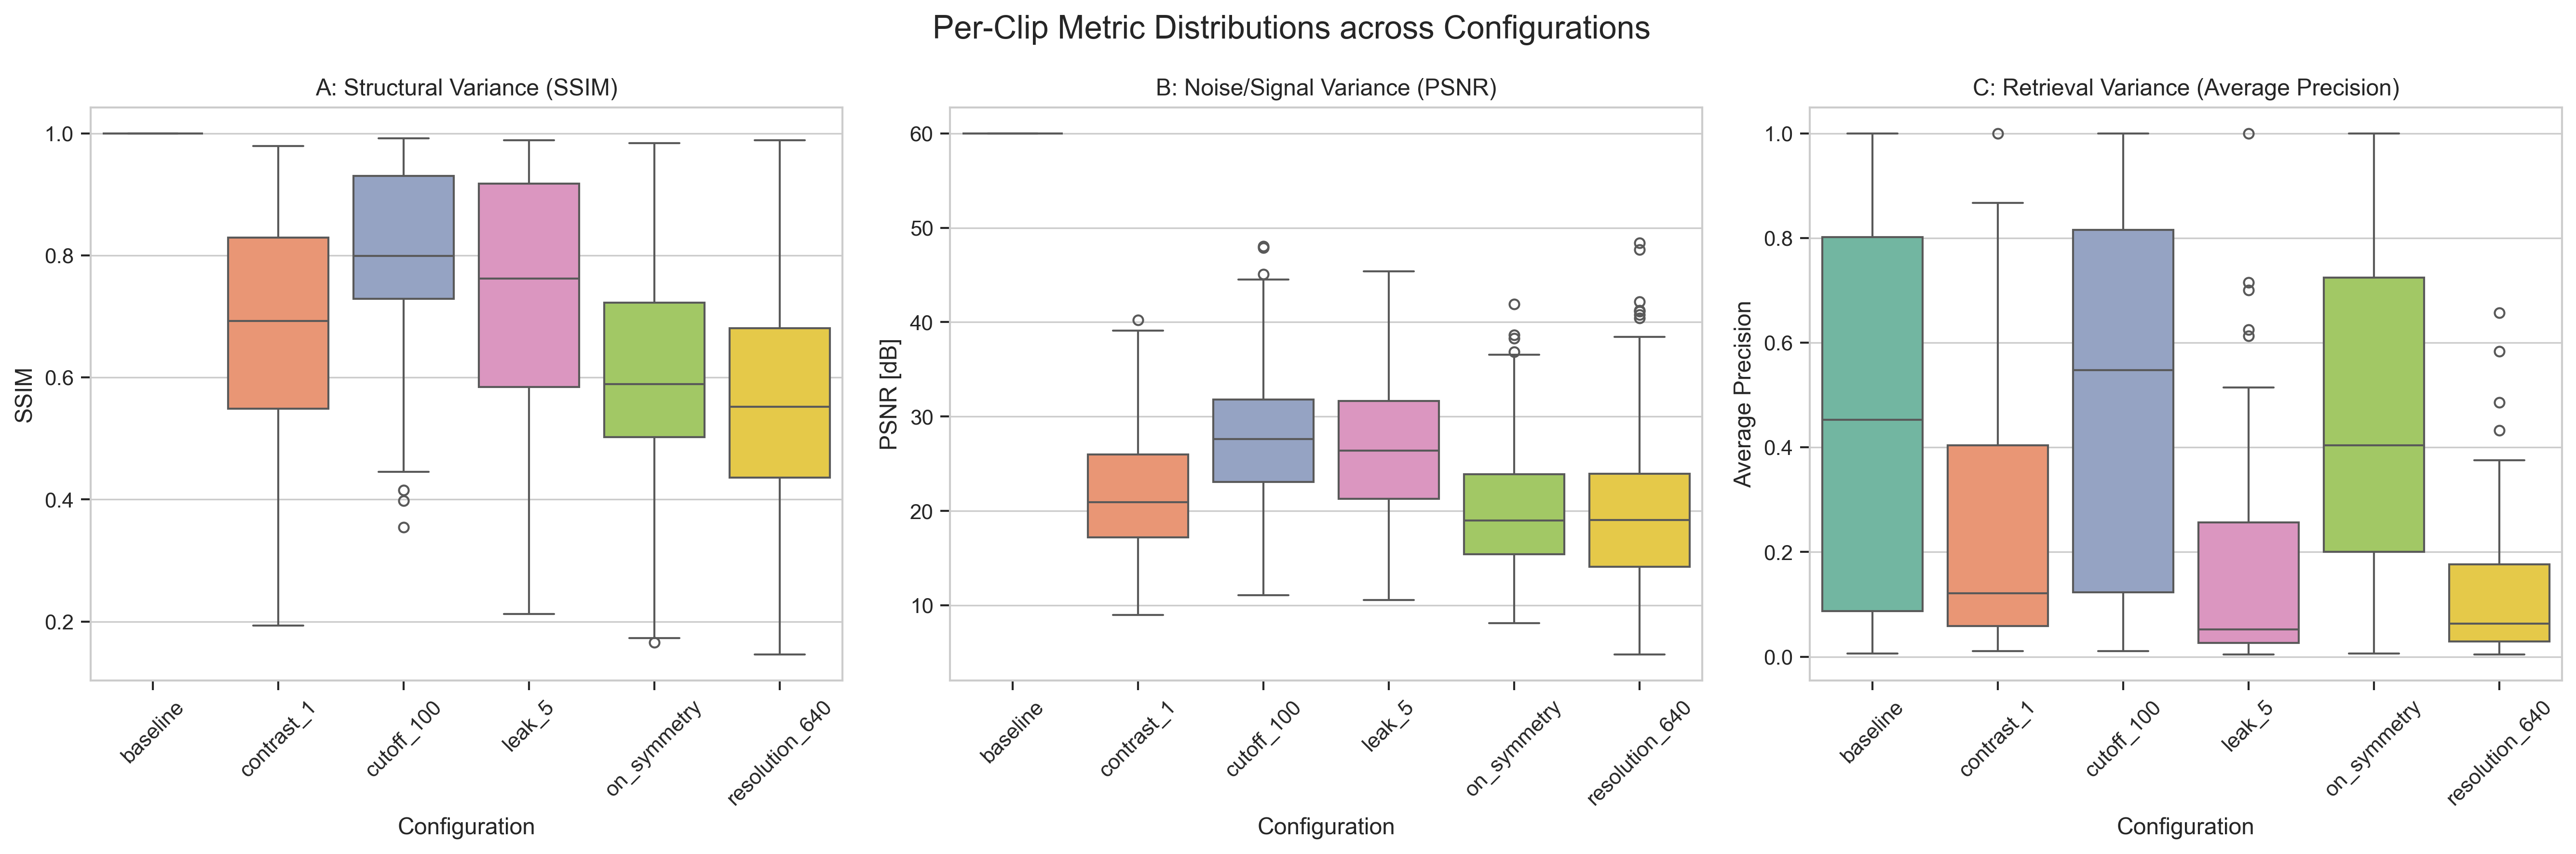

In [6]:
# Task 4: Raw Distributions
raw_dfs = []
for idx, row in df_macro.iterrows():
    csv_path = row['CSV_Path']
    if pd.notna(csv_path) and os.path.exists(csv_path):
        df_csv = pd.read_csv(csv_path)
        df_csv['Configuration'] = idx
        raw_dfs.append(df_csv)

df_raw = pd.concat(raw_dfs, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)
fig.suptitle('Per-Clip Metric Distributions across Configurations', fontsize=16)

# Plot A: SSIM Distribution
sns.boxplot(data=df_raw, x='Configuration', y='ssim', ax=axes[0], palette='Set2')
axes[0].set_title('A: Structural Variance (SSIM)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('SSIM')

# Plot B: PSNR Distribution
sns.boxplot(data=df_raw, x='Configuration', y='psnr', ax=axes[1], palette='Set2')
axes[1].set_title('B: Noise/Signal Variance (PSNR)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('PSNR [dB]')

# Plot C: Retrieval Variance
df_queries = df_raw[df_raw['is_query'] == True]
if not df_queries.empty and 'average_precision' in df_queries.columns:
    sns.boxplot(data=df_queries, x='Configuration', y='average_precision', ax=axes[2], palette='Set2')
    axes[2].set_title('C: Retrieval Variance (Average Precision)')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].set_ylabel('Average Precision')

plt.tight_layout()
plt.show()
